# Day 31 : Model Regularization

---

## Objectives:

- Understand **Model Regularization** and its importance.
- Learn about **Ridge Regression, Lasso Regression, and ElasticNet Regression**.
- Apply these techniques to prevent overfitting in machine learning models.
- Use a real-world dataset for hands-on practice.
- Visualize the impact of regularization on model performance.

---

## 1. Introduction to Model Regularization

### 1.1 What is Model Regularization?

Regularization is a technique used to **prevent overfitting** in machine learning models by adding a penalty to large coefficients in regression models. This helps improve **generalization** to unseen data.

### 1.2 Why Do We Need Regularization?

- Prevents overfitting by penalizing high-magnitude coefficients.
- Helps in **feature selection** (Lasso Regression shrinks some coefficients to zero).
- Improves model stability and interpretability.
- Works well with **multicollinearity** in datasets.

### 1.3 Types of Regularization Techniques

- **Ridge Regression (L2 Regularization)**: Penalizes the sum of squared coefficients.
- **Lasso Regression (L1 Regularization)**: Shrinks some coefficients to zero, performing feature selection.
- **ElasticNet Regression (Combination of L1 & L2)**: Provides a balance between Ridge and Lasso.

---

## 2. Dataset Overview

We'll use the **Diabetes Dataset** from Scikit-learn, which contains numerical features related to health and diabetes progression.

---
    

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

In [2]:
#Load Dataset
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [3]:
#Display first few rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


---

## 3. EDA

---


In [4]:
#Statistical Summary
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
#Check for missing values
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

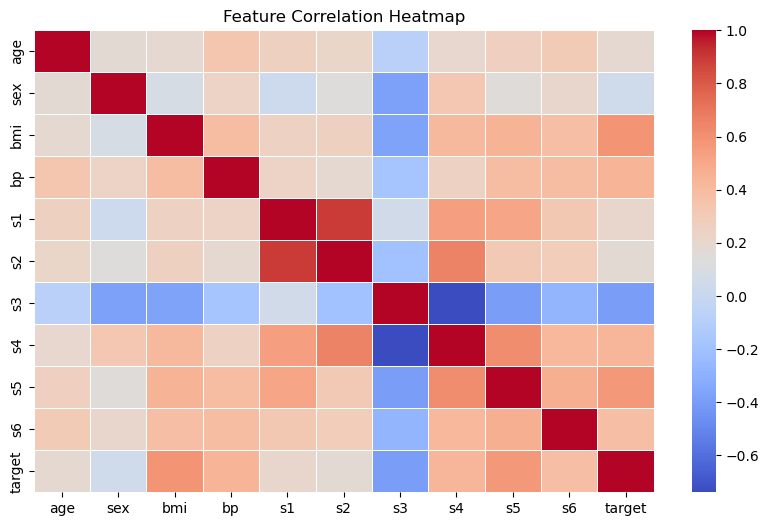

In [6]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, linewidth=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

---

## 4. Data Preprocessing

---

In [7]:
#Define feature variables(X) and target variable (y)
X = df.drop('target', axis=1)
y = df['target']

In [8]:
#split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [9]:
#Standardize Feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

## 5. Ridge Regression (L2 Regularization)

---

In [10]:
#Train Ridge Regression model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

Ridge()

In [11]:
#Prediction
y_pred_ridge = ridge.predict(X_test_scaled)

In [13]:
#Evaluate performance
print('Ridge Regression Metrics:')
print('MSE:' ,mean_squared_error(y_test, y_pred_ridge))
print('R2 Score:', r2_score(y_test, y_pred_ridge))

Ridge Regression Metrics:
MSE: 2892.014565750172
R2 Score: 0.45414652070698236


## 6. Lasso Regression (L1 Regularization)

---

In [14]:
# Train Lasso Regression Model
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

In [17]:
#Prediction
y_pred_lasso = lasso.predict(X_test_scaled)

In [16]:
print(np.isnan(X_test_scaled).sum())

0


In [18]:
#Evaluate Performance
print('Lasso Regression Metrics:')
print('MSE:', mean_squared_error(y_test, y_pred_lasso))
print('R2 Score:', r2_score(y_test, y_pred_lasso))

Lasso Regression Metrics:
MSE: 2884.624288735213
R2 Score: 0.455541399027904


---

## 7. ElasticNet Regression (L1 + L2 Regularization)

---

In [19]:
#Train ElasticNet Regression Model
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.1)

In [20]:
#Predictions
y_pred_elastic = elastic.predict(X_test_scaled)

In [21]:
#Evaluate Performance
print('ElasticNet Regression Metrics: ')
print('MSE:', mean_squared_error(y_test, y_pred_elastic))
print('R2 Score:', r2_score(y_test, y_pred_elastic))

ElasticNet Regression Metrics: 
MSE: 2866.4612552977674
R2 Score: 0.4589695819678379


---

## 8. Visualization
---

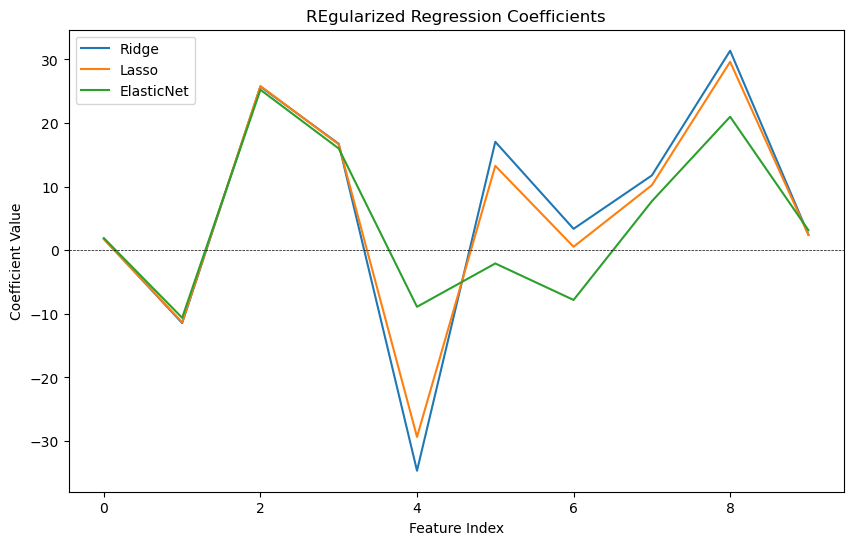

In [25]:
#compare coefficient magnitudes
plt.figure(figsize=(10,6))
plt.plot(ridge.coef_, label='Ridge')
plt.plot(lasso.coef_, label='Lasso')
plt.plot(elastic.coef_, label='ElasticNet')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend()
plt.title('REgularized Regression Coefficients')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.show()

## 9. Interpretation of Results

---

- **Ridge Regression**: Reduces coefficient magnitude but does not set any to zero.
- **Lasso Regression**: Shrinks some coefficients to zero, effectively performing feature selection.
- **ElasticNet Regression**: Combines Ridge and Lasso to achieve a balance between regularization and feature selection.

---

## 10. Conclusion

---
In this notebook, we:

✅ Explored Model Regularization and its importance in ML.<br>
✅ Implemented Ridge, Lasso, and ElasticNet Regression.<br>
✅ Evaluated their effects on model performance.<br>
✅ Used robust visualizations to compare regularization techniques.<br>

Regularization is crucial in preventing overfitting and improving model generalization! 🚀

---